Ура, картинка успешно загружена!


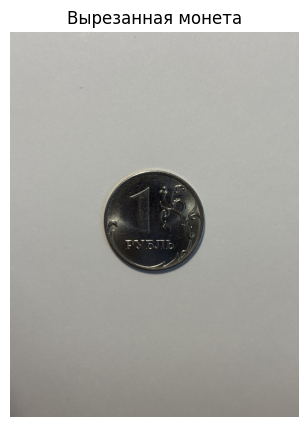

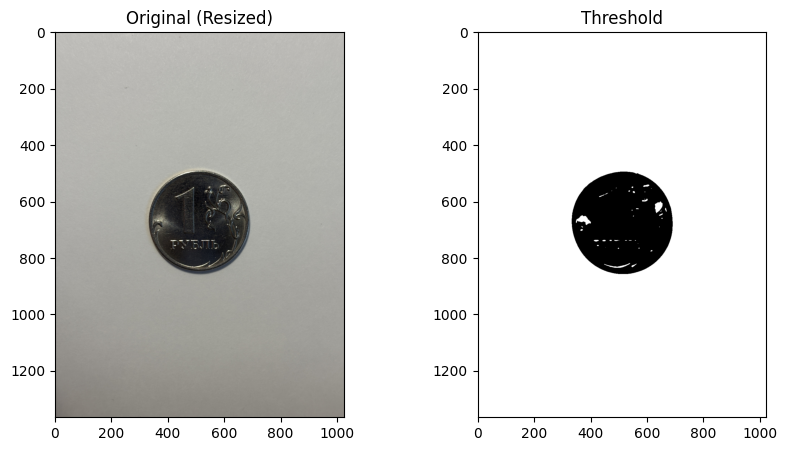

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Загружаем тестовое фото одиночной монеты
# Замени '1r_v1.jpg' на имя любого своего файла из папки singles
img_path = 'D:/практика 2 курс/university 2nd year practice/raw/singles/IMG_3814.JPG'

# Читаем файл как массив байт (ему плевать на кириллицу в пути)
img_array = np.fromfile(img_path, np.uint8)
# Декодируем массив в изображение OpenCV
img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

# Проверяем, что картинка точно загрузилась
if img is None:
    print(f"Ошибка! Не удалось загрузить файл по пути: {img_path}")
    print("Проверь, правильно ли написано имя файла и его расширение (.JPG или .jpg)")
else:
    # Если всё ок, переводим в RGB и идем дальше
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    print("Ура, картинка успешно загружена!")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Изменяем размер для удобства обработки (например, уменьшим в 4 раза)
h, w = img.shape[:2]
new_w = 1024
new_h = int(h * (new_w / w))
img_resized = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)

# 3. Переводим в Grayscale и размываем
gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (11, 11), 0)

# 4. Бинаризация (так как фон белый, а монета темнее, инвертируем порог)
# Все, что темнее фона, станет белым (монета), а фон — черным
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 5. Находим контуры на бинаризованном изображении
# Используем thresh_clean (или thresh, если ты не переименовывал переменную)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# На всякий случай фильтруем контуры, берем самый большой (это и есть наша монета)
if len(contours) > 0:
    c = max(contours, key=cv2.contourArea)

    # Получаем ограничивающий прямоугольник (x, y - левый верхний угол, w, h - ширина и высота)
    x, y, w, h = cv2.boundingRect(c)

    # Чтобы вырезанная монетка была ровным квадратом с небольшими отступами,
    # сделаем сторону квадрата равной максимальной стороне с запасом в 10 пикселей
    side = max(w, h) + 10

    # Вычисляем новый центр, чтобы не вылезти за границы кадра
    cx, cy = x + w // 2, y + h // 2

    x1 = max(0, cx - side // 2)
    y1 = max(0, cy - side // 2)
    x2 = min(img_resized.shape[1], cx + side // 2)
    y2 = min(img_resized.shape[0], cy + side // 2)

    # Вырезаем область (ROI - Region of Interest) из ЦВЕТНОГО уменьшенного изображения
    coin_crop = img_resized[y1:y2, x1:x2]

    # Показываем результат
    plt.figure(figsize=(5, 5))
    plt.title("Вырезанная монета")
    plt.imshow(coin_crop)
    plt.axis('off')
    plt.show()
else:
    print("Контуры не найдены!")




# Отобразим, что получилось на этом этапе
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original (Resized)")
plt.imshow(img_resized)
plt.subplot(1, 2, 2)
plt.title("Threshold")
plt.imshow(thresh, cmap='gray')
plt.show()